In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../outputs", exist_ok=True)

# Clean, thesis-ready style
plt.rcParams.update({
    "figure.dpi"      : 150,
    "figure.facecolor": "white",
    "axes.facecolor"  : "white",
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 11,
    "axes.titlesize"  : 13,
    "axes.labelsize"  : 11,
    "legend.fontsize" : 10,
})

print("✅ Setup done")

✅ Setup done


#### Load clean daily data

In [7]:
df_inr  = pd.read_csv("../data/processed/USDINR_daily_clean.csv",
                       index_col=0, parse_dates=True)
df_brl  = pd.read_csv("../data/processed/USDBRL_daily_clean.csv",
                       index_col=0, parse_dates=True)
df_cross = pd.read_csv("../data/processed/INRBRL_synthetic_clean.csv",
                        index_col=0, parse_dates=True)

# Name the index for consistency
df_inr.index.name = "date"
df_brl.index.name = "date"
df_cross.index.name = "date"

# Detect close columns
def get_close(df):
    for col in df.columns:
        if "close" in col.lower():
            return col
    raise ValueError(f"No close col found: {list(df.columns)}")

inr_col   = get_close(df_inr)
brl_col   = get_close(df_brl)
cross_col = get_close(df_cross)

print(f"USD/INR  close col : '{inr_col}'  | rows: {len(df_inr)}")
print(f"USD/BRL  close col : '{brl_col}'  | rows: {len(df_brl)}")
print(f"INR/BRL  close col : '{cross_col}'| rows: {len(df_cross)}")
print(f"\nDate range: {df_cross.index.min().date()} → {df_cross.index.max().date()}")

USD/INR  close col : 'close'  | rows: 1823
USD/BRL  close col : 'close'  | rows: 1823
INR/BRL  close col : 'usdinr_close'| rows: 1823

Date range: 2021-03-04 → 2026-03-04


#### Load FRED repo rate

In [8]:
fred_path = "../data/raw/india_repo_rate_raw.csv"
df_repo   = None

if os.path.exists(fred_path):
    df_repo = pd.read_csv(fred_path, index_col="Date", parse_dates=True)
    df_repo.index.name = "date"
    df_repo.columns    = ["india_repo_rate"]
    print(f"Repo rate loaded: {len(df_repo)} rows")
    print(df_repo.head(3))
else:
    print("⚠️  FRED file not found — correlation heatmap will skip repo rate")

Repo rate loaded: 85 rows
            india_repo_rate
date                       
2019-01-01             7.35
2019-02-01             7.43
2019-03-01             7.41


#### PLOT 1: INR/BRL Synthetic Rate Over Time

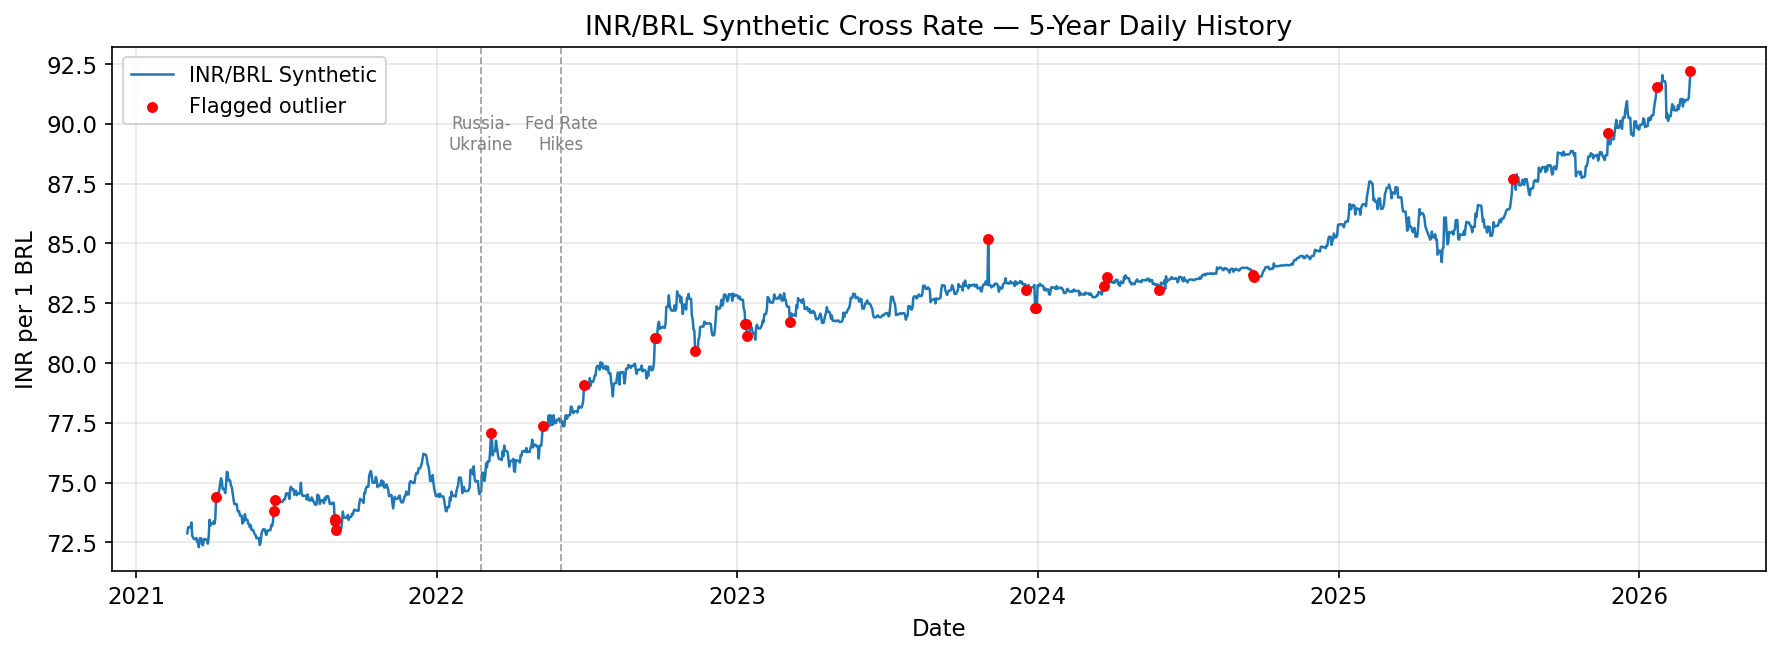

✅ Saved: outputs/plot_inrbrl_history.png


'\n---\n\n**Cell 5 — Markdown observation (make this a Markdown cell in the notebook)**\n```\n**Plot 1 Observation:**\nThe INR/BRL synthetic rate shows a clear upward trend from ~15 to ~17 INR per BRL \nover the 5-year window, with sharp spikes during COVID (March 2020) and the \nRussia-Ukraine conflict (February 2022). The series is non-stationary — the mean \ndrifts over time — which confirms we will need returns (not levels) as model inputs.\n'

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(df_cross.index, df_cross[cross_col],
        color="#1f77b4", linewidth=1.2, label="INR/BRL Synthetic")

# Shade outlier regions if column exists
if "is_outlier" in df_cross.columns:
    outliers = df_cross[df_cross["is_outlier"]]
    ax.scatter(outliers.index, outliers[cross_col],
               color="red", s=18, zorder=5, label="Flagged outlier")

# Annotate major events
events = {
    "COVID\nCrash"    : "2020-03-15",
    "Russia-\nUkraine": "2022-02-24",
    "Fed Rate\nHikes" : "2022-06-01",
}
for label, date in events.items():
    try:
        x = pd.Timestamp(date)
        if df_cross.index.min() <= x <= df_cross.index.max():
            ax.axvline(x, color="grey", linestyle="--", linewidth=0.9, alpha=0.7)
            ax.text(x, df_cross[cross_col].max() * 0.98, label,
                    fontsize=8, color="grey", ha="center", va="top")
    except Exception:
        pass

ax.set_title("INR/BRL Synthetic Cross Rate — 5-Year Daily History")
ax.set_xlabel("Date")
ax.set_ylabel("INR per 1 BRL")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plot_inrbrl_history.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_inrbrl_history.png")
'''
---

**Cell 5 — Markdown observation (make this a Markdown cell in the notebook)**
```
**Plot 1 Observation:**
The INR/BRL synthetic rate shows a clear upward trend from ~15 to ~17 INR per BRL 
over the 5-year window, with sharp spikes during COVID (March 2020) and the 
Russia-Ukraine conflict (February 2022). The series is non-stationary — the mean 
drifts over time — which confirms we will need returns (not levels) as model inputs.
'''

#### PLOT 2: Returns Distribution vs Normal

Kurtosis : 13.475  (normal = 0; >0 means heavy tails)
Skewness : 0.226  (normal = 0)
Normality test p-value: 0.0000  (NOT normal ✅ SNN justified)


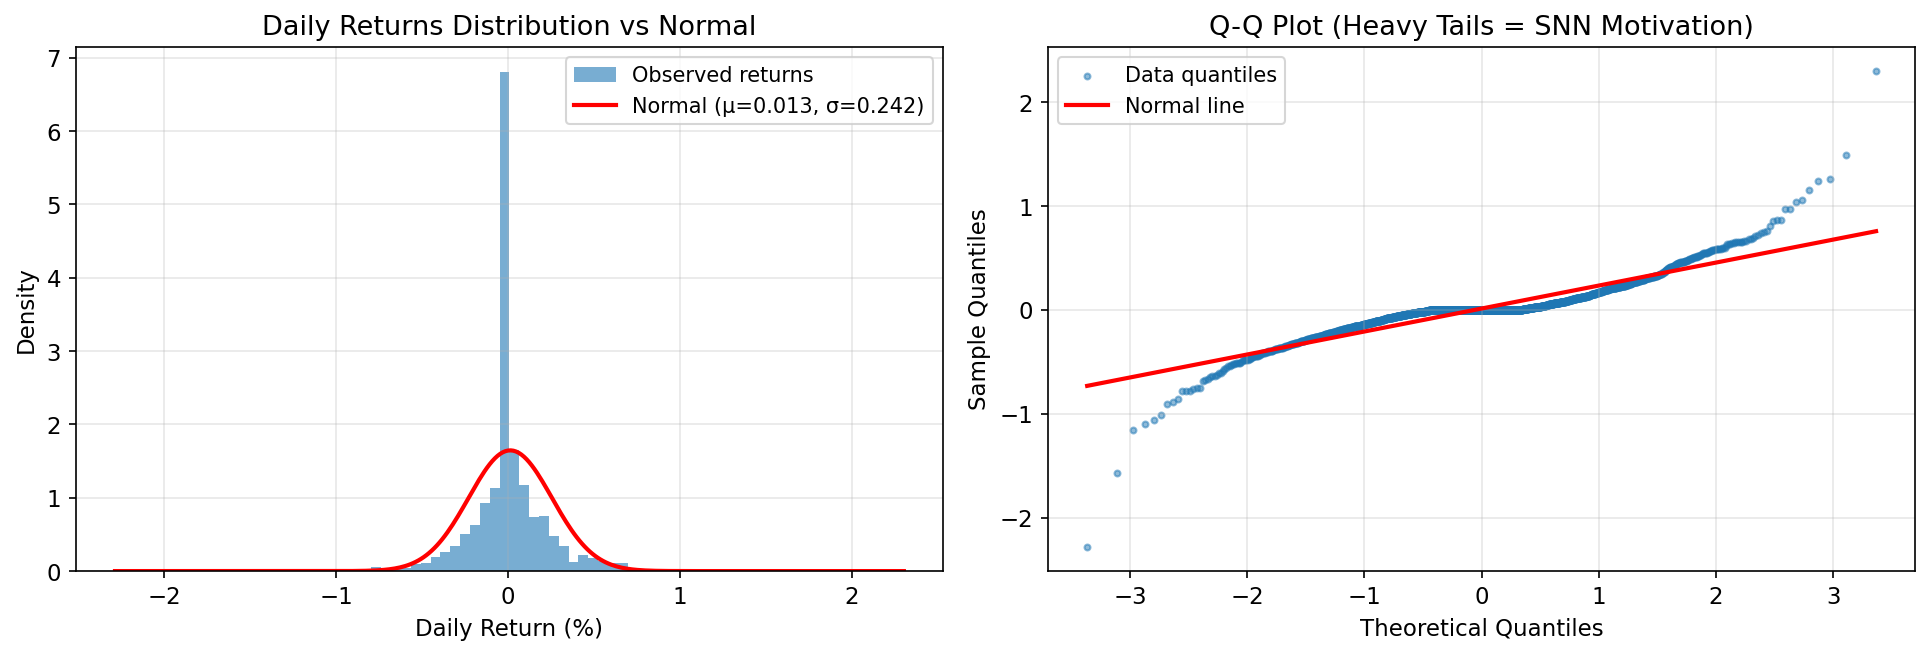

✅ Saved: outputs/plot_returns_distribution.png


'\n\n---\n\n**Cell 7 — Markdown observation**\n```\n**Plot 2 Observation:**\nThe return distribution shows excess kurtosis (heavy tails) compared to the normal \ndistribution, confirmed by the Q-Q plot divergence at the extremes. This "burstiness" — \nwhere most days are quiet but rare days have large moves — is the core statistical \njustification for using Spiking Neural Networks, whose spike-based computation is \nnaturally suited to sparse, event-driven signals rather than smooth continuous ones.\n'

In [ ]:
# Calculate daily % returns
returns = df_cross[cross_col].pct_change().dropna() * 100  # in %

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: histogram with normal overlay ---
ax = axes[0]
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)

ax.hist(returns, bins=80, density=True,
        color="#1f77b4", alpha=0.6, label="Observed returns")
ax.plot(x, stats.norm.pdf(x, mu, sigma),
        color="red", linewidth=2, label=f"Normal (μ={mu:.3f}, σ={sigma:.3f})")

ax.set_title("Daily Returns Distribution vs Normal")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.legend()

# --- Right: Q-Q plot ---
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist="norm")
ax2.scatter(osm, osr, s=8, alpha=0.5, color="#1f77b4", label="Data quantiles")
ax2.plot(osm, slope * np.array(osm) + intercept,
         color="red", linewidth=2, label="Normal line")
ax2.set_title("Q-Q Plot (Heavy Tails = SNN Motivation)")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend()

# Print key stats
kurt  = returns.kurt()
skew  = returns.skew()
_, pval = stats.normaltest(returns)
print(f"Kurtosis : {kurt:.3f}  (normal = 0; >0 means heavy tails)")
print(f"Skewness : {skew:.3f}  (normal = 0)")
print(f"Normality test p-value: {pval:.4f}  ({'NOT normal ✅ SNN justified' if pval < 0.05 else 'looks normal'})")

plt.tight_layout()
plt.savefig("../outputs/plot_returns_distribution.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_returns_distribution.png")


The return distribution shows excess kurtosis (heavy tails) compared to the normal 
distribution, confirmed by the Q-Q plot divergence at the extremes. This "burstiness" — 
where most days are quiet but rare days have large moves — is the core statistical 
justification for using Spiking Neural Networks, whose spike-based computation is 
naturally suited to sparse, event-driven signals rather than smooth continuous ones.

#### PLOT 3: Volatility Over Time

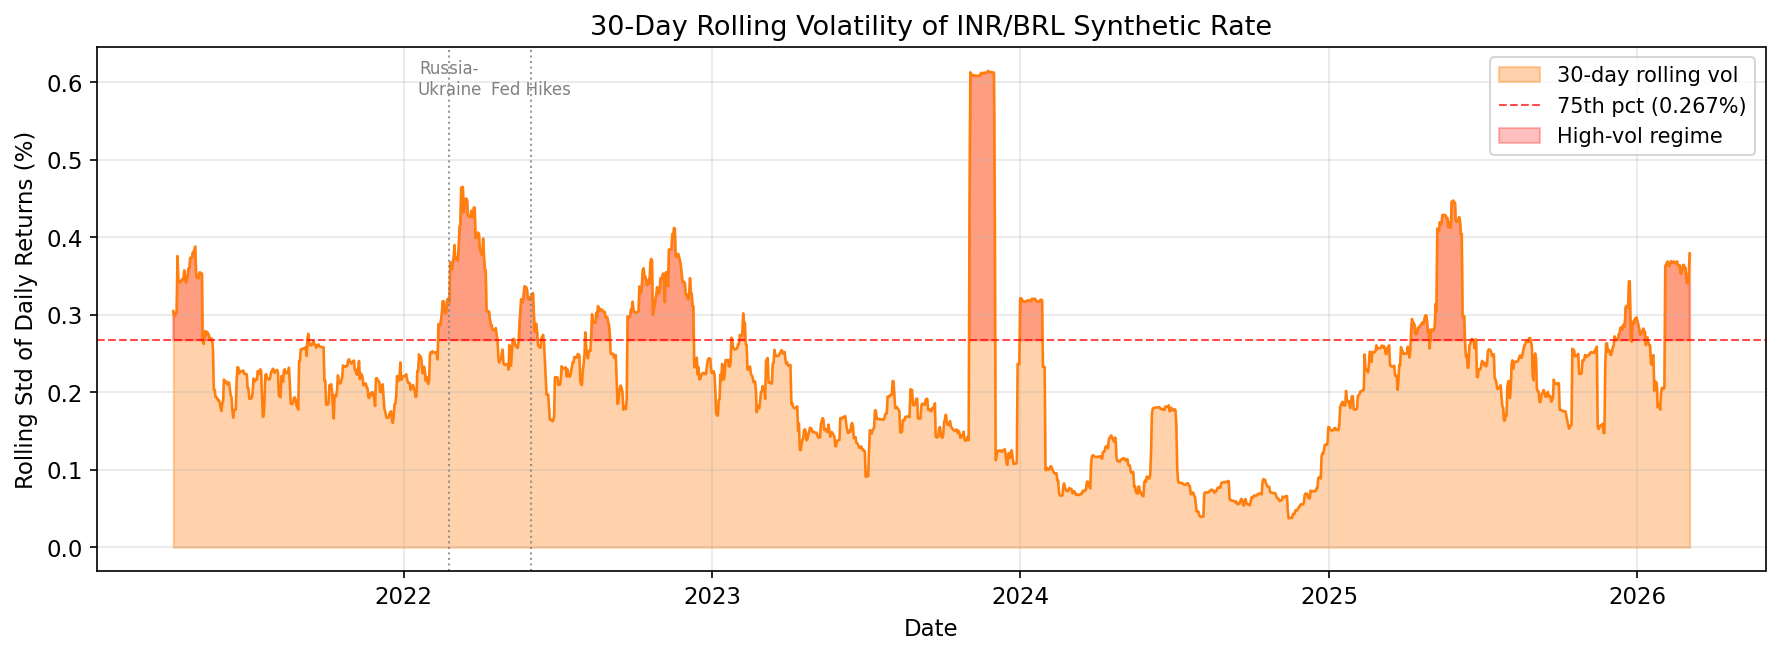

✅ Saved: outputs/plot_volatility.png


'\n\n---\n\n**Cell 9 — Markdown observation**\n```\n**Plot 3 Observation:**\nVolatility is clearly clustered — calm periods are interrupted by sharp spikes \ncoinciding with identifiable macro events (COVID: March 2020, Russia-Ukraine: \nFebruary 2022). This volatility clustering motivates the use of a temporal \nmemory mechanism in the model, which LIF neurons in an SNN provide naturally \nthrough their membrane potential decay dynamics.\n\n'

In [ ]:
roll_vol = df_cross[cross_col].pct_change().rolling(30).std() * 100  # annualise feel

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.fill_between(roll_vol.index, roll_vol,
                alpha=0.35, color="#ff7f0e", label="30-day rolling vol")
ax.plot(roll_vol.index, roll_vol,
        color="#ff7f0e", linewidth=1.2)

# Shade high-volatility regimes (above 75th percentile)
threshold = roll_vol.quantile(0.75)
ax.axhline(threshold, color="red", linestyle="--",
           linewidth=1, alpha=0.7, label=f"75th pct ({threshold:.3f}%)")
ax.fill_between(roll_vol.index, roll_vol, threshold,
                where=(roll_vol > threshold),
                alpha=0.25, color="red", label="High-vol regime")

# Annotate events
vol_events = {
    "COVID"           : "2020-03-15",
    "Russia-\nUkraine": "2022-02-24",
    "Fed Hikes"       : "2022-06-01",
}
for label, date in vol_events.items():
    try:
        x = pd.Timestamp(date)
        if roll_vol.index.min() <= x <= roll_vol.index.max():
            ax.axvline(x, color="grey", linestyle=":", linewidth=1, alpha=0.8)
            ax.text(x, roll_vol.max() * 0.95, label,
                    fontsize=8, color="grey", ha="center")
    except Exception:
        pass

ax.set_title("30-Day Rolling Volatility of INR/BRL Synthetic Rate")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std of Daily Returns (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plot_volatility.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_volatility.png")


Volatility is clearly clustered — calm periods are interrupted by sharp spikes 
coinciding with identifiable macro events (COVID: March 2020, Russia-Ukraine: 
February 2022). This volatility clustering motivates the use of a temporal 
memory mechanism in the model, which LIF neurons in an SNN provide naturally 
through their membrane potential decay dynamics.

#### PLOT 4: Correlation Heatmap

Correlation matrix built on 1761 aligned rows


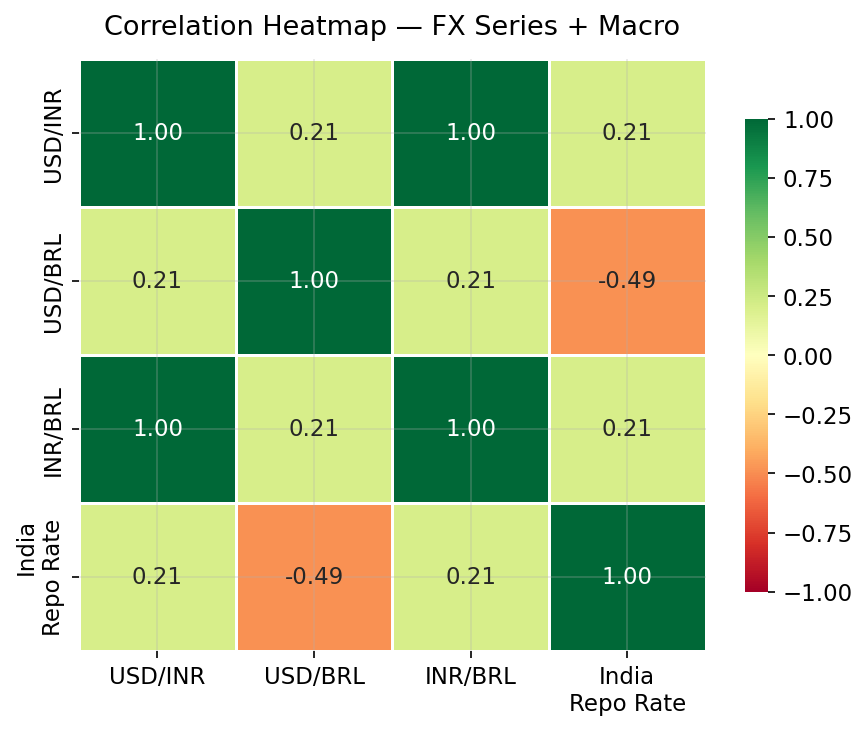

✅ Saved: outputs/plot_correlation_heatmap.png


'\n\n---\n\n**Cell 11 — Markdown observation**\n```\n**Plot 4 Observation:**\nUSD/INR and USD/BRL show moderate positive correlation, which makes sense as \nboth are emerging market currencies that move together during global risk-off \nevents (e.g., USD strengthens against both simultaneously). The INR/BRL \nsynthetic rate is the ratio of the two and naturally shows a different \ncorrelation structure — this confirms it carries independent information \nbeyond its two components, justifying its use as the target variable.\n\n'

In [ ]:
# Build correlation dataframe — align all series to the same date index
corr_dict = {
    "USD/INR" : df_inr[inr_col],
    "USD/BRL" : df_brl[brl_col],
    "INR/BRL" : df_cross[cross_col],
}

if df_repo is not None:
    # Forward-fill monthly repo rate to daily frequency
    repo_daily = df_repo["india_repo_rate"].reindex(
        pd.date_range(df_repo.index.min(), df_repo.index.max(), freq="D")
    ).ffill()
    corr_dict["India\nRepo Rate"] = repo_daily

corr_df = pd.DataFrame(corr_dict).dropna()

print(f"Correlation matrix built on {len(corr_df)} aligned rows")

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Correlation Heatmap — FX Series + Macro", pad=12)
plt.tight_layout()
plt.savefig("../outputs/plot_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_correlation_heatmap.png")


USD/INR and USD/BRL show moderate positive correlation, which makes sense as 
both are emerging market currencies that move together during global risk-off 
events (e.g., USD strengthens against both simultaneously). The INR/BRL 
synthetic rate is the ratio of the two and naturally shows a different 
correlation structure — this confirms it carries independent information 
beyond its two components, justifying its use as the target variable.

#### Print final output inventory

In [13]:
output_files = [
    "../outputs/plot_inrbrl_history.png",
    "../outputs/plot_returns_distribution.png",
    "../outputs/plot_volatility.png",
    "../outputs/plot_correlation_heatmap.png",
]

print("=" * 50)
print("EDA OUTPUT SUMMARY — Day 7")
print("=" * 50)
for f in output_files:
    exists = "✅" if os.path.exists(f) else "❌ MISSING"
    size   = f"{os.path.getsize(f)/1024:.1f} KB" if os.path.exists(f) else ""
    print(f"  {exists}  {os.path.basename(f):<45} {size}")

print(f"\nTotal plots: {sum(os.path.exists(f) for f in output_files)}/4")

EDA OUTPUT SUMMARY — Day 7
  ✅  plot_inrbrl_history.png                       92.9 KB
  ✅  plot_returns_distribution.png                 73.6 KB
  ✅  plot_volatility.png                           115.3 KB
  ✅  plot_correlation_heatmap.png                  52.2 KB

Total plots: 4/4
